In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import os
import torch
import csv
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.integrate import cumulative_trapezoid
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [75]:
def load_data(dataset_root='../FORTH_TRACE_DATASET', save_path='all_data.npy'):
    # Se o arquivo já existe, lê direto
    if os.path.exists(save_path):
        print("A carregar os dados do arquivo salvo...")
        return np.load(save_path)
    
    print("A ler os dados do CSV...")
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)
    
    # Salva em .npy para carregar rápido na próxima vez
    np.save(save_path, data)
    print(f"Dados salvos em {save_path}")
    
    return data

# Usar a função
data = load_data()
print(data[:5])
# Carregar dados
data = np.load('all_data.npy')
print(data.shape) # ver dimensão (linhas, colunas)
print(data[:5]) # mostrar as primeiras 5 linhas

A carregar os dados do arquivo salvo...
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]
(3930873, 13)
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.013

## 1.1

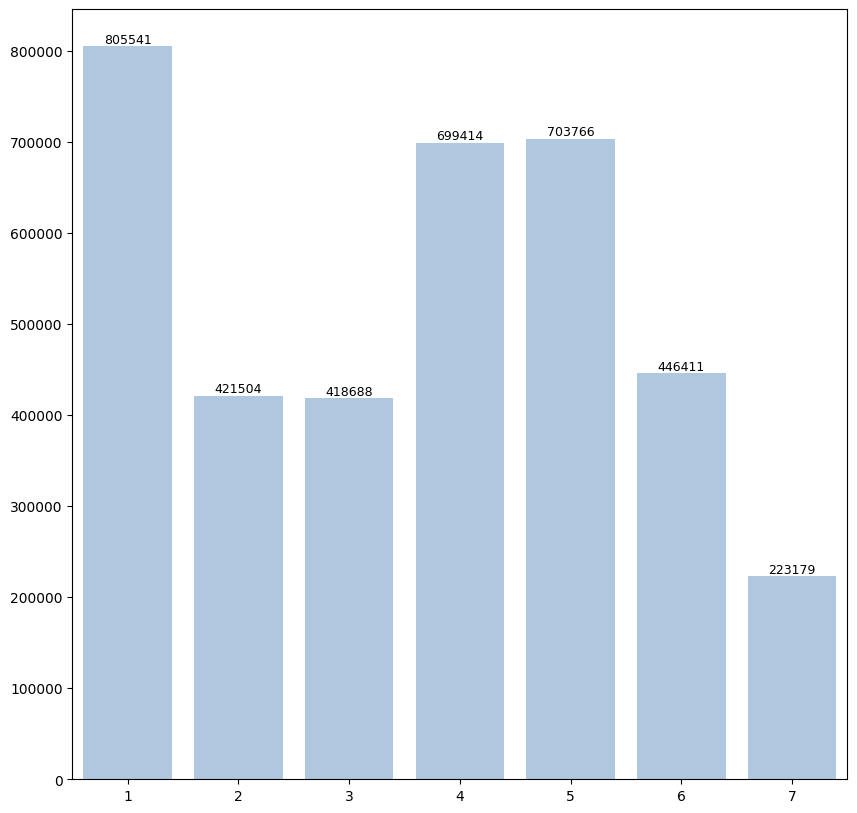

In [76]:
activity_labels = data[:, 12].astype(int)

# Filtrar apenas atividades 1 a 7
mask = (activity_labels >= 1) & (activity_labels <= 7)
data_filtered = data[mask]
filtered_labels = activity_labels[mask]

# Contar exemplos por atividade
atividades, contagens = np.unique(filtered_labels, return_counts=True)

# Plot com seaborn
plt.figure(figsize=(10,10))
grafico = sns.barplot(x=atividades, y=contagens, color='#A7C7E7')
grafico.bar_label(grafico.containers[0], fontsize=9)
plt.show()


## 1.2

In [77]:
def generate_smote_samples(X, y, activity_label, K, k_neighbors=5):

    current_count = np.sum(y == activity_label)
    target_count = current_count + K
    
    smote = SMOTE(
        sampling_strategy={activity_label: target_count},
        k_neighbors=k_neighbors
    )
    
    X_res, y_res = smote.fit_resample(X, y)
    dataset_augmented = np.hstack((X_res, y_res.reshape(-1,1)))
    return dataset_augmented


In [78]:
ignore_cols = [0, 1, 11, 12]
feature_cols = [i for i in range(data.shape[1]) if i not in ignore_cols]

df_norm = data.copy().astype(float)

scaler = StandardScaler()
df_norm[:, feature_cols] = scaler.fit_transform(data[:, feature_cols])

X = df_norm[:, feature_cols]          # apenas sensores
y = data[:, 12].astype(int)           # coluna do label

dataset_augmented = generate_smote_samples(X, y, activity_label=4, K=5)
print("Shape dataset_augmented:", dataset_augmented.shape)

Shape dataset_augmented: (3930878, 10)


## 1.3

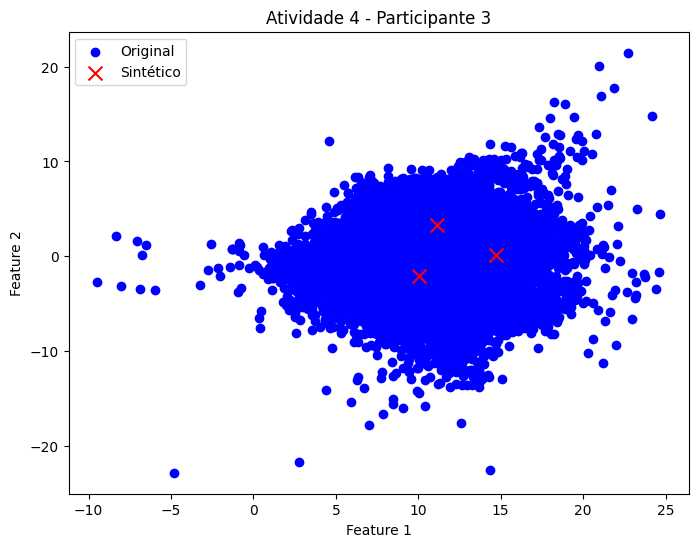

In [79]:
# Filtrar apenas participante 3
participant_id = 3
mask_participant = data[:, 0] == participant_id
data_participant = data[mask_participant]

# Separar features e label
feature_cols = list(range(2, 11))  # sensores
X_part = data_participant[:, feature_cols]
y_part = data_participant[:, 12].astype(int)

# Gerar 3 novas amostras para atividade 4
activity_label = 4
data_augmented = generate_smote_samples(X_part, y_part, activity_label=activity_label, K=3)

# --- 5. Separar exemplos ---
data_activity_original = data_participant[data_participant[:, 12] == activity_label]
num_original = data_activity_original.shape[0]

data_activity_augmented = data_augmented[data_augmented[:, -1] == activity_label]
original_samples = data_activity_augmented[:num_original]
synthetic_samples = data_activity_augmented[num_original:]

# Plotar o pedido
plt.figure(figsize=(8,6))
plt.scatter(original_samples[:, 1], original_samples[:, 2], color='blue', label='Original')
plt.scatter(synthetic_samples[:, 1], synthetic_samples[:, 2], color='red', label='Sintético', marker='x', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Atividade {activity_label} - Participante {participant_id}')
plt.legend()
plt.show()


-------------------------------------------------------------------------------

# Exercício 2 - Embedding Features

In [80]:
#codigo do stor do embedding 
def load_model():
  ''' Loads the model from the github repo and obtains just the feature encoder. '''

  repo = 'OxWearables/ssl-wearables'
  # class_num não interessa para extrair features; mas o hub pede este arg
  model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
  model.eval()

  # Passo crucial: ficar só com a parte auto-supervisionada
  # O README diz que há um 'feature_extractor' (pré-treinado) e um 'classifier' (não treinado). :contentReference[oaicite:14]{index=14}
  feature_encoder = model.feature_extractor
  feature_encoder.to("cpu")
  feature_encoder.eval()

  return feature_encoder


def resample_to_30hz_5s(acc_xyz, fs_in_hz):
    """
    acc_xyz: np.ndarray shape (N, 3) em m/s^2 (ou g), amostrado a fs_in_hz (float)
    devolve:
      acc_resampled: np.ndarray shape (M, 3) já a 30 Hz
      fs_target: 30.0
    """
    fs_target = 30.0
    win_size = 5 # in seconds
    t_in = np.arange(acc_xyz.shape[0]) / fs_in_hz
    t_out = np.arange(0, win_size, 1.0/fs_target)

    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)
    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_xyz[:, axis])

    return acc_resampled, fs_target


def acc_segmentation(data):
  ''' Estract ACC segments and their activities '''

  TIMESTAMP_COL = 10
  MIN_SEGMENT_SIZE = 20
  fs_in_hz = 51.2
  win_size = 5000
  start_time = data[0,TIMESTAMP_COL]
  end_time = start_time + win_size

  activities = []
  segments = []

  while end_time < data[-1,TIMESTAMP_COL]:
    mask = (data[:,TIMESTAMP_COL] >= start_time) & (data[:,TIMESTAMP_COL] < end_time)

    if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):

      acc_xyz = data[mask,1:4]
      activity = data[mask, -1][0]
      
      activities.append(activity)
      segments.append( acc_xyz )
      

    start_time = end_time - win_size/2
    end_time = start_time + win_size
  
  
  return segments, activities



# load example file to test embedding
csv_file_path = '../FORTH_TRACE_DATASET/part13/part13dev1.csv'
 
csv_data = np.loadtxt(csv_file_path, delimiter=',')

original_segments, activities = acc_segmentation(csv_data)

resampled_segments = [resample_to_30hz_5s(segment, 51.2)[0] for segment in original_segments]

feature_encoder = load_model()

embeddings_list = []

# reshape segments to [n_segments, dimensions(xyz), time]
x_all = np.transpose( np.array(resampled_segments), (0, 2, 1) )
print(x_all.shape)

# iterate over the resampled segments and pass them 
#    through the model in batches to get the embeddings
batch_size = 5
with torch.no_grad():
    for i in range(0, x_all.shape[0], batch_size):
        xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
        eb = feature_encoder(xb)  # (B, D_embed)
        embeddings_list.append(eb.cpu().numpy())

embeddings = np.concatenate(embeddings_list, axis=0)
print(embeddings.shape)

Using cache found in C:\Users\bmsam/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
(369, 3, 150)
(369, 512, 1)


In [81]:
embeddings_list = []

base_path = '../FORTH_TRACE_DATASET'

for part_id in range(15):  # participantes de 0 a 14
    part_folder = os.path.join(base_path, f'part{part_id}')
    
    #todos os CSVs da pasta
    csv_files = sorted([f for f in os.listdir(part_folder) if f.endswith('.csv')])
    
    for csv_file in csv_files:
        csv_file_path = os.path.join(part_folder, csv_file)
        csv_data = np.loadtxt(csv_file_path, delimiter=',')
        
        # segmentar
        segments, activities = acc_segmentation(csv_data)
        
        # Filtrar apenas atividades 1 a 7
        segments_filtered = []
        participant_filtered = []
        activities_filtered= []
        for seg, act in zip(segments, activities):
            if 1 <= act <= 7:
                segments_filtered.append(seg)
                participant_filtered.append(part_id) 
                activities_filtered.append(act)

        if len(segments_filtered) == 0:
            continue
        
        # resample para 30Hz
        resampled_segments = [resample_to_30hz_5s(seg, 51.2)[0] for seg in segments_filtered]
        x_all = np.array([seg.T for seg in resampled_segments], dtype=np.float32)
        
        # extrair embeddings
        batch_size = 5
        with torch.no_grad():
            for i in range(0, x_all.shape[0], batch_size):
                xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
                eb = feature_encoder(xb)
                eb_np = eb.cpu().numpy()
                
                for j, seg_emb in enumerate(eb_np):
                    embeddings_list.append(
                        np.hstack([
                            participant_filtered[i+j],
                            seg_emb.flatten(),
                            activities_filtered[i+j]
                        ])
                    )

# concatenar todos os participantes
embeddings_dataset = np.array(embeddings_list, dtype=np.float32)  
print(f"Shape final do embeddings_dataset (linhas x features+pid+atividade): {embeddings_dataset.shape}")

# exemplo
for pid in range(15):
    part_mask = embeddings_dataset[:,0] == pid
    part_data = embeddings_dataset[part_mask]
    if part_data.shape[0] == 0:
        continue
    print(f"Participante {pid} -> {part_data.shape[0]} segmentos")
    print("Exemplo de embedding (primeira linha, primeiras 10 dimensões):")
    print(part_data[0,:12]) 
    print("-"*30)

Shape final do embeddings_dataset (linhas x features+pid+atividade): (27699, 514)
Participante 0 -> 1846 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[0.         0.         0.         0.         0.         0.02860497
 0.05294336 0.         0.04316683 0.         0.04375382 0.10662704]
------------------------------
Participante 1 -> 1844 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[1.         0.         0.         0.         0.         0.02128764
 0.03353288 0.         0.04632877 0.         0.03986754 0.08333381]
------------------------------
Participante 2 -> 1847 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[2.         0.         0.         0.         0.         0.01461428
 0.01896847 0.         0.0651965  0.         0.02664905 0.08372725]
------------------------------
Participante 3 -> 1849 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[3.         0.         0.         0.

[participant_id, activity, embedding_1, embedding_2, ..., embedding_512]
como esta o dataset

---------------------------------

# Exercício 3 - Data splitting strategy

### 3.1

duvida: aqui é necessario que todas as atividades aparecam nos 3 conjuntos ou basta os participantes

# Feature Set

In [82]:
def create_windows(data, fs, window_length=5.0, overlap=0.5):
    n_samples_window = int(fs * window_length)
    step = int(n_samples_window * (1 - overlap))
    windows = []

    pessoas = np.unique(data[:, 0])

    for pessoa in pessoas:
        pessoa_data = data[data[:, 0] == pessoa]
        dispositivos = np.unique(pessoa_data[:, 1])

        for dispositivo in dispositivos:
            sub_data = pessoa_data[pessoa_data[:, 1] == dispositivo]
            n_samples = len(sub_data)

            # sliding windows normais
            for start_idx in range(0, n_samples - n_samples_window + 1, step):
                end_idx = start_idx + n_samples_window
                window_data = sub_data[start_idx:end_idx]
                labels = window_data[:, 12]
                if np.all(labels == labels[0]):
                    windows.append(window_data)

            # incluir última janela incompleta
            if n_samples % step != 0:
                start_idx = n_samples - n_samples_window
                if start_idx < 0:
                    start_idx = 0
                window_data = sub_data[start_idx:]
                labels = window_data[:, 12]
                if np.all(labels == labels[0]):
                    windows.append(window_data)

    return windows
windows = create_windows(data, fs=51.2, window_length=5.0, overlap=0.5)
np.save("windows.npy", np.array(windows))

In [83]:
nomes_features = [
    'person_id',
    # ax
    'ax_mean','ax_median','ax_std','ax_var','ax_rms','ax_mean_derivative','ax_skewness','ax_kurtosis','ax_iqr','ax_zcr','ax_mcr',
    'ax_SpecEntropy','ax_DominantFreq','ax_Energy',
    # ay
    'ay_mean','ay_median','ay_std','ay_var','ay_rms','ay_mean_derivative','ay_skewness','ay_kurtosis','ay_iqr','ay_zcr','ay_mcr',
    'ay_SpecEntropy','ay_DominantFreq','ay_Energy',
    # az
    'az_mean','az_median','az_std','az_var','az_rms','az_mean_derivative','az_skewness','az_kurtosis','az_iqr','az_zcr','az_mcr',
    'az_SpecEntropy','az_DominantFreq','az_Energy',
    # gx
    'gx_mean','gx_median','gx_std','gx_var','gx_rms','gx_mean_derivative','gx_skewness','gx_kurtosis','gx_iqr','gx_zcr','gx_mcr',
    'gx_SpecEntropy','gx_DominantFreq','gx_Energy',
    # gy
    'gy_mean','gy_median','gy_std','gy_var','gy_rms','gy_mean_derivative','gy_skewness','gy_kurtosis','gy_iqr','gy_zcr','gy_mcr',
    'gy_SpecEntropy','gy_DominantFreq','gy_Energy',
    # gz
    'gz_mean','gz_median','gz_std','gz_var','gz_rms','gz_mean_derivative','gz_skewness','gz_kurtosis','gz_iqr','gz_zcr','gz_mcr',
    'gz_SpecEntropy','gz_DominantFreq','gz_Energy',
    # mx
    'mx_mean','mx_median','mx_std','mx_var','mx_rms','mx_mean_derivative','mx_skewness','mx_kurtosis','mx_iqr','mx_zcr','mx_mcr',
    'mx_SpecEntropy','mx_DominantFreq','mx_Energy',
    # my
    'my_mean','my_median','my_std','my_var','my_rms','my_mean_derivative','my_skewness','my_kurtosis','my_iqr','my_zcr','my_mcr',
    'my_SpecEntropy','my_DominantFreq','my_Energy',
    # mz
    'mz_mean','mz_median','mz_std','mz_var','mz_rms','mz_mean_derivative','mz_skewness','mz_kurtosis','mz_iqr','mz_zcr','mz_mcr',
    'mz_SpecEntropy','mz_DominantFreq','mz_Energy',

    # Features gerais
    'Corr_Acc_XY','Corr_Acc_XZ','Corr_Acc_YZ',
    'Corr_Gyr_XY','Corr_Gyr_XZ','Corr_Gyr_YZ',
    'Corr_Mag_XY','Corr_Mag_XZ','Corr_Mag_YZ',
    'MI_mean','MI_var',
    'SMA',
    'EVA_Acc_1','EVA_Acc_2',
    'Corr_Acc_Gravity_Heading',
    'AvgVelHeading','AvgVelGravity',
    'AvgRotAngleGravity',
    'AvgAccEnergy',
    'AvgRotEnergy',
    # incluir a label no final
    'label']

In [84]:
def calculate_features (windows):
        features = []
        labels= []
        fs= 51.2
        for window in windows:
                window_features = []
                window_label = window[0, 12]
                if window_label <= 7 and window_label >= 1:
                        pers_id = window[0, 0]
                        labels.append(window_label)

                        for col in range(2, 11):
                                coluna = window[:, col]
                                N = len(coluna)
                                mean_col = np.mean(coluna)

                                #temporal features
                                #média
                                window_features.append(mean_col)

                                #mediana
                                window_features.append(np.median(coluna))

                                #desvião padrão
                                window_features.append(np.std(coluna))

                                #variância
                                window_features.append(np.var(coluna))

                                #raíz quadrada da média  
                                window_features.append(np.sqrt(np.mean(coluna**2)))

                                #derivda média
                                window_features.append(np.mean(np.diff(coluna)))

                                #skewness
                                window_features.append(stats.skew(coluna))

                                #Kurtosis
                                window_features.append(stats.kurtosis(coluna)) 

                                #IQR
                                window_features.append(stats.iqr(coluna))

                                #zero crossing rate    
                                window_features.append(len (np.where(np.diff(np.sign(coluna)))[0])/N)

                                #mean corssing rate
                                window_features.append(len (np.where(np.diff(np.sign(coluna - mean_col)))[0])/N)

                                #spectral features ------------
                                fft_col = np.fft.rfft(coluna)
                                fft_energy = np.abs(fft_col)**2
                                fft_freqs = np.fft.rfftfreq(N, 1/fs)

                                #Spectral Entropy 
                                psd = fft_energy[1:]
                                psd_norm = psd / np.sum(psd)
                                spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
                                window_features.append(spectral_entropy)

                                # Dominant Frequency
                                dominant_freq = fft_freqs[np.argmax(fft_energy)]
                                window_features.append(dominant_freq)

                                #Energy
                                energy = np.sum(psd) / N
                                window_features.append(energy)

                        #pairwise correlation----------
                        # Accelerometer correlations
                        acc = window[:, 2:5]
                        corr_acc = np.corrcoef(acc.T)[np.triu_indices(3, 1)]
                        window_features.extend(corr_acc)
                        # Gyroscope correlations
                        gyr = window[:, 5:8]
                        corr_gyr = np.corrcoef(gyr.T)[np.triu_indices(3, 1)]
                        window_features.extend(corr_gyr)
                        # Magnetometer correlations
                        mag = window[:, 8:11]
                        corr_mag = np.corrcoef(mag.T)[np.triu_indices(3, 1)]
                        window_features.extend(corr_mag)

                        #Movement intensity --> temporal
                        ax, ay, az = window[:, 2], window[:, 3], window[:, 4]
                        mi = np.sqrt(np.mean(ax**2) + np.mean(ay**2) + np.mean(az**2))
                        window_features.extend([np.mean(mi), np.var(mi)])

                        #normalized signal magnitude area (SMA) --> temporal
                        T = len(ax)
                        sma = (np.sum(np.abs(ax)) + np.sum(np.abs(ay)) + np.sum(np.abs(az))) / T
                        window_features.append(sma)

                        # EVA --> temporal
                        eva_acc = np.sort(np.linalg.eigvals(np.cov(window[:, 2:5] - np.mean(window[:, 2:5], axis=0), rowvar=False)))[::-1][:2]
                        window_features.extend(eva_acc)

                        # Correlation between Acceleration along Gravity and Heading Directions --> temporal
                        a_heading = np.sqrt(ay**2 + az**2)
                        window_features.append(np.corrcoef(ax, a_heading)[0, 1])

                        # Averaged Velocity along Gravity Direction --> temporal
                        t = window[:, 11]
                        vy = cumulative_trapezoid(ay, t, initial=0)
                        vz = cumulative_trapezoid(az, t, initial=0)
                        vx = cumulative_trapezoid(ax, t, initial=0)
                        avh = np.sqrt(np.mean(vy)**2 + np.mean(vz)**2)
                        avg = np.mean(vx)
                        window_features.extend([avh, avg])

                        # Averaged Rotation Angle along Gravity Direction --> temporal
                        gx = window[:, 5]
                        theta_x = cumulative_trapezoid(gx, t, initial=0)
                        window_features.append(np.mean(theta_x))

                        # Averaged Acceleration Energy --> spectral
                        acc_block = window[:, 2:5]  # ax, ay, az
                        fft_acc = np.fft.rfft(acc_block, axis=0)
                        energy_acc = np.sum((np.abs(fft_acc)**2)[1:, :], axis=0) / acc_block.shape[0]
                        AEE = np.mean(energy_acc)
                        window_features.append(AEE)

                        # Averaged Rotation Energy --> spectral
                        gyr_block = window[:, 5:8]  # gx, gy, gz
                        fft_gyr = np.fft.rfft(gyr_block, axis=0)
                        energy_gyr = np.sum((np.abs(fft_gyr)**2)[1:, :], axis=0) / gyr_block.shape[0]
                        ARE = np.mean(energy_gyr)
                        window_features.append(ARE)

                        features.append([pers_id] + window_features)
        feature_set_with_labels = np.column_stack((features, labels)) 
        return feature_set_with_labels
#feature_set = calculate_features(windows)

In [85]:
#features = pd.DataFrame(feature_set, columns=nomes_features)
#features.to_csv('features_dataset.csv', header=nomes_features, index=False)
feature_dataset = pd.read_csv('features_dataset.csv').to_numpy()

print("Shape do FEATURE DATASET (atividades 1 a 7):", feature_dataset.shape)
print(feature_dataset[:5])

participants_data = {}
for part_id in range(15):
    part_rows = feature_dataset[feature_dataset[:, 0] == part_id]
    if len(part_rows) > 0:
        participants_data[part_id] = part_rows

for pid, pdata in participants_data.items():
    print(f"Participante {pid} -> {pdata.shape[0]} linhas")
    
    
# quais têm dados 
print("Participantes com dados:", list(participants_data.keys()))
print("Número de participantes com dados:", len(participants_data))

Shape do FEATURE DATASET (atividades 1 a 7): (27918, 148)
[[ 0.00000000e+00 -1.71878555e+00 -1.71330000e+00  8.88482084e-02
   7.89400413e-03  1.72108040e+00  4.54117647e-04 -2.86346009e-01
   1.92488234e-01  1.04025000e-01  0.00000000e+00  1.25000000e-01
   4.53747721e+00  0.00000000e+00  1.01056507e+00  9.36300859e+00
   9.37530000e+00  6.63270502e-02  4.39927758e-03  9.36324352e+00
   1.29019608e-04 -7.69729438e-01  1.35445619e-01  9.02000000e-02
   0.00000000e+00  1.87500000e-01  4.18512947e+00  0.00000000e+00
   5.63211211e-01  2.53714180e+00  2.47070000e+00  1.52909124e-01
   2.33812002e-02  2.54174540e+00 -6.33333333e-04  7.61732179e-01
  -8.32688693e-01  2.71050000e-01  0.00000000e+00  6.64062500e-02
   2.04689830e+00  0.00000000e+00  2.99280106e+00 -9.42287738e-01
  -8.52360000e-01  1.95766030e+00  3.83243383e+00  2.17263435e+00
  -9.11372549e-04 -1.68788998e+00  5.54697476e+00  1.70152300e+00
   6.25000000e-02  1.09375000e-01  2.91599912e+00  0.00000000e+00
   4.90555600e+02 

In [86]:
# features
features_train_list = []
features_val_list = []
features_test_list = []

for id_p, pdata in participants_data.items():
    # 1º split
    train, temp = train_test_split(pdata, test_size=0.4, random_state=42, shuffle=True)
    # Use a TVT split of 60%-20%-20% split, within each subject (data of a single subject is present in all sets)
    # 2º split
    val, test = train_test_split(temp, test_size=0.5, random_state=42, shuffle=True)
    
    features_train_list.append(train)
    features_val_list.append(val)
    features_test_list.append(test)

# concatena todos os participantes
features_train = np.vstack(features_train_list)
features_val = np.vstack(features_val_list)
features_test = np.vstack(features_test_list)

print("FEATURES TRAIN:", features_train.shape)
print("FEATURES VAL:", features_val.shape)
print("FEATURES TEST:", features_test.shape)



print("-------")

# embeddings
emb_train_list = []
emb_val_list = []
emb_test_list = []

for pid in range(15):
    part_mask = embeddings_dataset[:,0] == pid
    part_data = embeddings_dataset[part_mask]
    
    train_x, temp_x = train_test_split(part_data, test_size=0.4, random_state=42, shuffle=True)
    val_x, test_x = train_test_split(temp_x, test_size=0.5, random_state=42, shuffle=True)
    
    emb_train_list.append(train_x)
    emb_val_list.append(val_x)
    emb_test_list.append(test_x)

# concatena todos os participantes
emb_train = np.concatenate(emb_train_list, axis=0)
emb_val = np.concatenate(emb_val_list, axis=0)
emb_test = np.concatenate(emb_test_list, axis=0)

print("EMBEDDINGS TRAIN:", emb_train.shape)
print("EMBEDDINGS VAL:", emb_val.shape)
print("EMBEDDINGS TEST:", emb_test.shape)


FEATURES TRAIN: (16744, 148)
FEATURES VAL: (5585, 148)
FEATURES TEST: (5589, 148)
-------
EMBEDDINGS TRAIN: (16613, 514)
EMBEDDINGS VAL: (5539, 514)
EMBEDDINGS TEST: (5547, 514)


In [87]:
# Mostrar primeiras 5 linhas do FEATURES TRAIN
print("FEATURES TRAIN (primeiras 5 linhas)")
print(features_train[:5])
print("-"*30)

# Mostrar primeiras 5 linhas do EMBEDDINGS TRAIN
print("EMBEDDINGS TRAIN (primeiras 5 linhas)")
print(emb_train[:5, :12])  # PID, atividade + primeiras 10 dimensões
print("-"*30)

# Mostrar primeiras 5 linhas do FEATURES TRAIN
print("FEATURES VALID (primeiras 5 linhas)")
print(features_val[:5])
print("-"*30)

# Mostrar primeiras 5 linhas do EMBEDDINGS TRAIN
print("EMBEDDINGS VALID (primeiras 5 linhas)")
print(emb_val[:5, :12])  # PID, atividade + primeiras 10 dimensões
print("-"*30)

# Mostrar primeiras 5 linhas do FEATURES TRAIN
print("FEATURES TEST (primeiras 5 linhas)")
print(features_test[:5])
print("-"*30)

# Mostrar primeiras 5 linhas do EMBEDDINGS TRAIN
print("EMBEDDINGS TEST (primeiras 5 linhas)")
print(emb_test[:5, :12])  # PID, atividade + primeiras 10 dimensões
print("-"*30)

FEATURES TRAIN (primeiras 5 linhas)
[[ 0.00000000e+00  2.26835754e+00  2.03255000e+00  5.16674555e+00
   2.66952596e+01  5.64275691e+00 -1.02227451e-02 -8.79669399e-02
   5.50618459e+00  4.19365250e+00  1.13281250e-01  1.79687500e-01
   6.09737180e+00  0.00000000e+00  3.43457504e+03  9.51450832e+00
   9.63960000e+00  4.43062829e+00  1.96304670e+01  1.04955388e+01
  -1.96094118e-02 -4.30568126e-01  1.77855403e+00  3.54057500e+00
   1.56250000e-02  1.91406250e-01  5.03817038e+00  0.00000000e+00
   2.51510935e+03 -4.87944468e-01 -1.16865000e+00  3.21517398e+00
   1.03373437e+01  3.25198917e+00  6.92549020e-04  1.08899311e+00
   2.33771029e+00  3.31282500e+00  1.32812500e-01  1.71875000e-01
   5.81645244e+00  6.00000000e-01  1.33039768e+03  9.46786879e+00
   5.18980000e+00  5.68081248e+01  3.22716304e+03  5.75916971e+01
   6.02605490e-01  2.53774369e-01  9.93957334e-02  6.02010000e+01
   8.98437500e-02  6.64062500e-02  3.92432013e+00  1.40000000e+00
   4.13149015e+05  4.25762099e+01  2.609

### 3.2

In [88]:
all_participants = np.arange(15)

#para ser aleatorio
np.random.seed(42) 
shuffled = np.random.permutation(all_participants)

train_participants = shuffled[:9]
val_participants   = shuffled[9:12]
test_participants  = shuffled[12:]
print("Treino (features & embeddings):", train_participants)
print("Validação (features & embeddings):", val_participants)
print("Teste (features & embeddings):", test_participants)


def filter_by_participants(dataset, participants):
    mask = np.isin(dataset[:, 0], participants)
    return dataset[mask]

# feature
features_train_subj = filter_by_participants(feature_dataset, train_participants)
features_val_subj   = filter_by_participants(feature_dataset, val_participants)
features_test_subj  = filter_by_participants(feature_dataset, test_participants)

print("\n------")
print("FEATURES TRAIN:", features_train_subj.shape)
print("FEATURES VAL  :", features_val_subj.shape)
print("FEATURES TEST :", features_test_subj.shape)



#embeddings
emb_train_subj = filter_by_participants(embeddings_dataset, train_participants)
emb_val_subj   = filter_by_participants(embeddings_dataset, val_participants)
emb_test_subj  = filter_by_participants(embeddings_dataset, test_participants)

print("\n------")
print("EMBEDDINGS TRAIN:", emb_train_subj.shape)
print("EMBEDDINGS VAL  :", emb_val_subj.shape)
print("EMBEDDINGS TEST :", emb_test_subj.shape)

Treino (features & embeddings): [ 9 11  0 13  5  8  2  1 14]
Validação (features & embeddings): [ 4  7 10]
Teste (features & embeddings): [12  3  6]

------
FEATURES TRAIN: (16763, 148)
FEATURES VAL  : (5471, 148)
FEATURES TEST : (5684, 148)

------
EMBEDDINGS TRAIN: (16545, 514)
EMBEDDINGS VAL  : (5565, 514)
EMBEDDINGS TEST : (5589, 514)


In [89]:
# Features
print("FEATURES TRAIN (primeiras 5 linhas)")
print(features_train_subj[:5])
print("------------------------------")

print("FEATURES VAL (primeiras 5 linhas)")
print(features_val_subj[:5])
print("------------------------------")

print("FEATURES TEST (primeiras 5 linhas)")
print(features_test_subj[:5])
print("------------------------------")

# Embeddings
print("EMBEDDINGS TRAIN (primeiras 5 linhas)")
print(emb_train_subj[:5])
print("------------------------------")

print("EMBEDDINGS VAL (primeiras 5 linhas)")
print(emb_val_subj[:5])
print("------------------------------")

print("EMBEDDINGS TEST (primeiras 5 linhas)")
print(emb_test_subj[:5])
print("------------------------------")


FEATURES TRAIN (primeiras 5 linhas)
[[ 0.00000000e+00 -1.71878555e+00 -1.71330000e+00  8.88482084e-02
   7.89400413e-03  1.72108040e+00  4.54117647e-04 -2.86346009e-01
   1.92488234e-01  1.04025000e-01  0.00000000e+00  1.25000000e-01
   4.53747721e+00  0.00000000e+00  1.01056507e+00  9.36300859e+00
   9.37530000e+00  6.63270502e-02  4.39927758e-03  9.36324352e+00
   1.29019608e-04 -7.69729438e-01  1.35445619e-01  9.02000000e-02
   0.00000000e+00  1.87500000e-01  4.18512947e+00  0.00000000e+00
   5.63211211e-01  2.53714180e+00  2.47070000e+00  1.52909124e-01
   2.33812002e-02  2.54174540e+00 -6.33333333e-04  7.61732179e-01
  -8.32688693e-01  2.71050000e-01  0.00000000e+00  6.64062500e-02
   2.04689830e+00  0.00000000e+00  2.99280106e+00 -9.42287738e-01
  -8.52360000e-01  1.95766030e+00  3.83243383e+00  2.17263435e+00
  -9.11372549e-04 -1.68788998e+00  5.54697476e+00  1.70152300e+00
   6.25000000e-02  1.09375000e-01  2.91599912e+00  0.00000000e+00
   4.90555600e+02 -5.43982020e-01 -3.313

*features_dataset*
as colunas representam : 
- coluna 0: ID do participante
- Coluna 1: device ID 
- coluna 2 a 11: valores das features
- coluna 12: timestamp
- coluna 13: label da atividade


*embeddings_dataset*
- Coluna 0: participant_id
- Coluna 1 a 512: embeddings (512 dimensões)
- Coluna 513: activity(label)

### 3.3

No 3.1 cada participante contribui com dados de treino, validação e teste.
- Ou seja, cada participante está dividido em dados de treino, validação e teste. 
- Isto pode fazer com que o modelo aprenda padrões individuais daquele participante  

No 3.2 cada participante só está num dos conjuntos de dados: ou no de teste, ou de treino ou de validação.
- O modelo aqui não conhece padrões especificos de cada participante e por isso se calhar esta estratégia é mais realista



A melhor estratégia para ser aplicada aos novos participantes é então a 2º porque o modelo ainda não viu dados do mesmo individuo e consegue generalizar para novos participantes.

### 3.4. 
Prepare your pipeline in a way that, after the split, for each dataset, you can compute and transform each set into three different scenarios:
1. All features/embeddings dataset
2. PCA-reduced features/embeddings dataset (keeping just the components
that explain 90% of the variance)
3. Feature-selected features/embeddings (keeping just the top 15 features
selected by the ReliefF method).

#### a)

In [93]:
# Exercício 3.1 (60% train -20% val -20% test split)

# --- Features com split por 60-20-20 ---
X_feat_train_all = features_train[:, 1:-1]  # features (exceto pid e label)
y_feat_train_all = features_train[:, -1].astype(int)    # label
X_feat_val_all = features_val[:, 1:-1]
y_feat_val_all = features_val[:, -1].astype(int)
X_feat_test_all = features_test[:, 1:-1]
y_feat_test_all = features_test[:, -1].astype(int)
# --- Embeddings com split por 60-20-20 ---
X_emb_train_all = emb_train[:, 1:-1]  # todas as features exceto individuo e label
y_emb_train_all = emb_train[:, -1].astype(int)    # label
X_emb_val_all = emb_val[:, 1:-1]
y_emb_val_all = emb_val[:, -1].astype(int)
X_emb_test_all = emb_test[:, 1:-1]
y_emb_test_all = emb_test[:, -1].astype(int)

# Exercício 3.2 (split por subject (9 train, 3 val, 3 test))

# --- Features com split por subject ---
X_feat_train_subj = features_train_subj[:, 1:-1]  # todas as features exceto individuo e label
y_feat_train_subj = features_train_subj[:, -1].astype(int)    # label
X_feat_val_subj = features_val_subj[:, 1:-1]
y_feat_val_subj = features_val_subj[:, -1].astype(int)
X_feat_test_subj = features_test_subj[:, 1:-1]
y_feat_test_subj = features_test_subj[:, -1].astype(int)
# --- Embeddings com split por subject ---
X_emb_train_subj = emb_train_subj[:, 1:-1]  # todas as features exceto individuo e label
y_emb_train_subj = emb_train_subj[:, -1].astype(int)    # label
X_emb_val_subj = emb_val_subj[:, 1:-1]
y_emb_val_subj = emb_val_subj[:, -1].astype(int)
X_emb_test_subj = emb_test_subj[:, 1:-1]
y_emb_test_subj = emb_test_subj[:, -1].astype(int)

## Normalização dos dados

In [94]:
# ==================== NORMALIZAÇÃO 3.1 (60-20-20) ====================

# Features - Normalizar
feat_scaler_31 = StandardScaler()
X_feat_train_all_scaled = feat_scaler_31.fit_transform(X_feat_train_all)
X_feat_val_all_scaled = feat_scaler_31.transform(X_feat_val_all)
X_feat_test_all_scaled = feat_scaler_31.transform(X_feat_test_all)

# Embeddings - Normalizar
emb_scaler_31 = StandardScaler()
X_emb_train_all_scaled = emb_scaler_31.fit_transform(X_emb_train_all)
X_emb_val_all_scaled = emb_scaler_31.transform(X_emb_val_all)
X_emb_test_all_scaled = emb_scaler_31.transform(X_emb_test_all)

# ==================== NORMALIZAÇÃO 3.2 (por subject) ====================

# Features - Normalizar
feat_scaler_32 = StandardScaler()
X_feat_train_subj_scaled = feat_scaler_32.fit_transform(X_feat_train_subj)
X_feat_val_subj_scaled = feat_scaler_32.transform(X_feat_val_subj)
X_feat_test_subj_scaled = feat_scaler_32.transform(X_feat_test_subj)

# Embeddings - Normalizar
emb_scaler_32 = StandardScaler()
X_emb_train_subj_scaled = emb_scaler_32.fit_transform(X_emb_train_subj)
X_emb_val_subj_scaled = emb_scaler_32.transform(X_emb_val_subj)
X_emb_test_subj_scaled = emb_scaler_32.transform(X_emb_test_subj)

## para o exercicio 3.2

#### b)

In [95]:
def apply_pca(X_train, X_val, X_test, variance_threshold=0.90):
    pca = PCA(n_components=variance_threshold, svd_solver='full')
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)
    
    print(f"PCA - Número de componentes mantidos: {pca.n_components_}")
    return X_train_pca, X_val_pca, X_test_pca

In [96]:
print ("-- 3.1 --")
# Features
X_feat_train_pca, X_feat_val_pca, X_feat_test_pca = apply_pca(
    X_feat_train_all_scaled, X_feat_val_all_scaled, X_feat_test_all_scaled
)
# Embeddings
X_emb_train_pca, X_emb_val_pca, X_emb_test_pca = apply_pca(
    X_emb_train_all_scaled, X_emb_val_all_scaled, X_emb_test_all_scaled
)
# Mostrar shapes PCA
print("FEATURES TRAIN PCA w 602020:", X_feat_train_pca.shape)
print("EMBEDDINGS TRAIN PCA w 602020:", X_emb_train_pca.shape)

print("-- 3.2 --")

# Features
X_feat_train_subj_pca, X_feat_val_subj_pca, X_feat_test_subj_pca = apply_pca(
    X_feat_train_subj_scaled, X_feat_val_subj_scaled, X_feat_test_subj_scaled
)
# Embeddings
X_emb_train_subj_pca, X_emb_val_subj_pca, X_emb_test_subj_pca = apply_pca(
    X_emb_train_subj_scaled, X_emb_val_subj_scaled, X_emb_test_subj_scaled
)

# Mostrar shapes PCA
print("FEATURES TRAIN PCA w subj:", X_feat_train_subj_pca.shape)
print("EMBEDDINGS TRAIN PCA w subj:", X_emb_train_subj_pca.shape)

-- 3.1 --
PCA - Número de componentes mantidos: 53
PCA - Número de componentes mantidos: 11
FEATURES TRAIN PCA w 602020: (16744, 53)
EMBEDDINGS TRAIN PCA w 602020: (16613, 11)
-- 3.2 --
PCA - Número de componentes mantidos: 51
PCA - Número de componentes mantidos: 11
FEATURES TRAIN PCA w subj: (16763, 51)
EMBEDDINGS TRAIN PCA w subj: (16545, 11)


#### c)

In [97]:
def reliefF_select(X, y, n_neighbors=10, n_features_select=15, 
                              random_state=42, sample_size=5000):
    """
    Aplica ReliefF no X e y (já separados) e retorna as n_features_select mais importantes.
    
    Parâmetros:
    - dataset: numpy array com coluna 0 = individuo, última coluna = label
    - n_neighbors: número de vizinhos para ReliefF
    - n_features_select: número de features a retornar
    - random_state: para reprodutibilidade
    - sample_size: número de exemplos a usar para calcular ReliefF (para não explodir memória)
    
    Retorna:
    - reduced_df: DataFrame com top features + individuo + label
    - selected_columns: lista dos nomes das features selecionadas
    - weights: vetor de pesos das features originais
    """
    np.random.seed(random_state)
    n_samples, n_features = X.shape
    
    # --- amostragem para grandes datasets ---
    if n_samples > sample_size:
        idx = np.random.choice(n_samples, sample_size, replace=False)
        X_sample, y_sample = X[idx], y[idx]
    else:
        X_sample, y_sample = X, y
    
    n_samples_sample = X_sample.shape[0]
    weights = np.zeros(n_features)
    
    # ReliefF: percorre exemplos aleatórios da amostra
    for _ in range(n_samples_sample):
        i = np.random.randint(0, n_samples_sample)
        xi, yi = X_sample[i], y_sample[i]
        
        same_class = np.where(y_sample == yi)[0]
        diff_class = np.where(y_sample != yi)[0]
        
        same_dists = np.sum((X_sample[same_class] - xi)**2, axis=1)
        diff_dists = np.sum((X_sample[diff_class] - xi)**2, axis=1)
        
        near_hits_idx = same_class[np.argsort(same_dists)[1:n_neighbors+1]]
        near_misses_idx = diff_class[np.argsort(diff_dists)[:n_neighbors]]
        
        near_hits = X_sample[near_hits_idx]
        near_misses = X_sample[near_misses_idx]
        
        for j in range(n_features):
            hit_term = np.sum((xi[j] - near_hits[:, j])**2) / n_neighbors
            miss_term = np.sum((xi[j] - near_misses[:, j])**2) / n_neighbors
            weights[j] += miss_term - hit_term
    
    weights /= n_samples_sample
    selected_indices = np.argsort(weights)[::-1][:n_features_select]
    
    return selected_indices, weights


In [98]:
def apply_relieff_pipeline(X_train, y_train, X_val, X_test, n_features_select=15):
    """Aplica ReliefF: calcula no train, aplica em todos"""
    selected_indices, weights = reliefF_select(X_train, y_train, n_features_select=n_features_select)
    
    X_train_relief = X_train[:, selected_indices]
    X_val_relief = X_val[:, selected_indices]
    X_test_relief = X_test[:, selected_indices]
    
    print(f"ReliefF - Top {n_features_select} features selecionadas")
    return X_train_relief, X_val_relief, X_test_relief, selected_indices


3.1

In [99]:
# --- 3.1 (60-20-20) ---
X_feat_train_relief, X_feat_val_relief, X_feat_test_relief, feat_indices = apply_relieff_pipeline(
    X_feat_train_all_scaled, y_feat_train_all, X_feat_val_all_scaled, X_feat_test_all_scaled
)
X_emb_train_relief, X_emb_val_relief, X_emb_test_relief, emb_indices = apply_relieff_pipeline(
    X_emb_train_all_scaled, y_emb_train_all, X_emb_val_all_scaled, X_emb_test_all_scaled
)

# --- 3.2 (por subject 9-3-3) ---
X_feat_train_subj_relief, X_feat_val_subj_relief, X_feat_test_subj_relief, feat_indices_subj = apply_relieff_pipeline(
    X_feat_train_subj_scaled, y_feat_train_subj, X_feat_val_subj_scaled, X_feat_test_subj_scaled
)
X_emb_train_subj_relief, X_emb_val_subj_relief, X_emb_test_subj_relief, emb_indices_subj = apply_relieff_pipeline(
    X_emb_train_subj_scaled, y_emb_train_subj, X_emb_val_subj_scaled, X_emb_test_subj_scaled
)

ReliefF - Top 15 features selecionadas
ReliefF - Top 15 features selecionadas
ReliefF - Top 15 features selecionadas
ReliefF - Top 15 features selecionadas


-------------------------------------------------------------------------------

## 4 - Model learning
We will now train a model to automatically classify the activity of each segment. We will use k-Nearest Neighbors.

### 4.1
Implement a k-Nearest Neighbors classifier (we expect you to implement your own version, but then you can use the sci-kit learn version if you need better performance. See information in [sklearn_KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)).

In [120]:
# Each line is a segment (window of 5 seconds with 50% overlap)
# Inside each windows the first index is a window, second is a column (variable) and each window contains x lines from the original dataset.

class KNNClassifier:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        if len(self.X_train) != len(self.y_train):
            raise ValueError("O Número de amostras em X e y têm de ser igual.")
        
    def _euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))
    
    def predict(self, X):
        X_test = np.array(X)
        predictions = []

        for test_point in X_test:
            # Calcukar distâncias para todos os pontos de treino
            distances = np.linalg.norm(self.X_train - test_point, axis=1)
            # Obter os índices dos k vizinhos mais próximos
            k_indices = np.argsort(distances)[:self.k]
            # Obter as labels dos k vizinhos
            k_nearest_labels = self.y_train[k_indices]
            # Aprovar por maioria
            most_common = np.bincount(k_nearest_labels.astype(int)).argmax()
            predictions.append(most_common)

        return np.array(predictions)

class KNNClassifierGPU:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
        # Deteta se há GPU disponível, caso contrário usa a CPU
        # estamos com problemas com a instalação do torch-cuda portanto fica
        # com a CPU mas o objetivo seria mesmo aproveitar a GPU
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"KNN inicializado no dispositivo: {self.device}")

    def fit(self, X, y):
        # Converte os dados para tensores e envia para a GPU
        # X(distancia entre pontos) = float & y(classes) = long/int
        self.X_train = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.y_train = torch.tensor(y, dtype=torch.long).to(self.device)
        
        if len(self.X_train) != len(self.y_train):
            raise ValueError("O Número de amostras em X e y tem de ser igual.")

    def predict(self, X):
        # Enviar os dados de teste para a Gráfica
        X_test = torch.tensor(X, dtype=torch.float32).to(self.device)

        # --- Calcular distâncias ---
        # Utilizar o cdist para calcular a matriz de distâncias NxM. (+ rápido que um loop)
        # p=2 para a distância euclidiana
        # dists = (num_test_samples, num_train_samples)
        dists = torch.cdist(X_test, self.X_train, p=2)

        # --- Obter os índices dos k vizinhos mais próximos ---
        # topk retorna os maiores valores
        # largest=False para ter as menores distâncias
        # dim = 1 porque queremos os vizinhos para cada amostra de teste
        knns = dists.topk(self.k, largest=False, dim=1)
        knn_indices = knns.indices

        # --- Obter as labels dos k vizinhos ---
        # Ir buscar as classes correspondentes ao y_train através dos índices
        # neighbor_labels shape = (num_test_samples, k)
        neighbor_labels = self.y_train[knn_indices]

        # --- Aprovar por maioria (Votação) ---
        # torch.mode retorna o valor mais frequente em cada linha
        # (values, indices) = torch.mode(...)
        predictions, _ = torch.mode(neighbor_labels, dim=1)

        # Devolve para o CPU e converte para numpy array (para manter compatibilidade)
        return predictions.cpu().numpy()

# Usar
#gpu_knn = KNNClassifierGPU(k=5)
#gpu_knn.fit(X_train, y_train)
#y_pred = gpu_knn.predict(X_test)

### 4.2
Create a function that receives two lists of values: the true labels and predicted labels, and returns a set of classification metrics: confusion matrix, accuracy, f1 score, precision, recall, etc.

In [101]:
def evaluate_model(labels_set, y_pred):
    print(metrics.classification_report(labels_set, y_pred))
    print(metrics.confusion_matrix(labels_set, y_pred))

-------------------------------------------------------------------------------

## 5 - Model evaluation
For each splitting strategy (2) applied for the 3 versions (all feats, PCA feats, ReliefF feats) of the 2 datasets (features, embeddings), train the classifier and evaluate its results:

### 5.1 Hyperparameter tuning
Select the best value of k using only the train and validation data. Then, with the best k, retrain with the dataset (train + validation) and evaluate on the test set.

### Função para testar diversos K

In [121]:
def find_best_k(X_train, y_train, X_val, y_val, k_values=[3, 5, 7, 9, 11, 15, 17, 19, 21]):
    best_k = k_values[0]
    best_f1 = 0.0
    results = []

    for k in k_values:
        knn = KNNClassifierGPU(k=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_val)
        
        acc = metrics.accuracy_score(y_val, y_pred)
        f1_macro = metrics.f1_score(y_val, y_pred, average='macro')
        f1_weighted = metrics.f1_score(y_val, y_pred, average='weighted')
        
        results.append({
            'k': k,
            'accuracy': acc,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted
        })
        
        if f1_macro > best_f1:
            best_f1 = f1_macro
            best_k = k
    
    return best_k, best_f1, results

### Função para testar a pipeline completa

In [122]:
def full_evaluation_pipeline(X_train, y_train, X_val, y_val, X_test, y_test, name=""):
    """Pipeline completo: tuning + re-treino + avaliação final com múltiplas métricas"""
    
    # 1. Encontrar melhor k
    best_k, val_f1, results = find_best_k(X_train, y_train, X_val, y_val)
    print(f"\n{'='*50}")
    print(f"[{name}]")
    print(f"Melhor k: {best_k} (F1 macro validação: {val_f1:.4f})")
    
    # 2. Re-treinar com train + validation
    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])
    
    knn_final = KNNClassifierGPU(k=best_k)
    knn_final.fit(X_train_full, y_train_full)
    
    # 3. Avaliar no test com múltiplas métricas
    y_pred_test = knn_final.predict(X_test)
    
    test_acc = metrics.accuracy_score(y_test, y_pred_test)
    test_f1_macro = metrics.f1_score(y_test, y_pred_test, average='macro')
    test_f1_weighted = metrics.f1_score(y_test, y_pred_test, average='weighted')
    test_precision = metrics.precision_score(y_test, y_pred_test, average='macro')
    test_recall = metrics.recall_score(y_test, y_pred_test, average='macro')
    
    print(f"\n--- Métricas no TEST ---")
    print(f"Accuracy:     {test_acc:.4f}")
    print(f"F1 Macro:     {test_f1_macro:.4f}")
    print(f"F1 Weighted:  {test_f1_weighted:.4f}")
    print(f"Precision:    {test_precision:.4f}")
    print(f"Recall:       {test_recall:.4f}")
    
    print(f"\nClassification Report:")
    print(metrics.classification_report(y_test, y_pred_test))
    print(f"Confusion Matrix:")
    print(metrics.confusion_matrix(y_test, y_pred_test))
    
    return {
        'name': name,
        'best_k': best_k,
        'val_f1': val_f1,
        'test_acc': test_acc,
        'test_f1_macro': test_f1_macro,
        'test_f1_weighted': test_f1_weighted,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'y_pred': y_pred_test,
        'y_true': y_test,
        'k_results': results
    }

In [125]:
all_results = []

# ==================== SPLIT 3.1 (60-20-20) ====================
print("\n" + "="*60)
print("SPLIT 3.1 - 60-20-20 (NORMALIZADO)")
print("="*60)

# Features - USAR DADOS NORMALIZADOS
all_results.append(full_evaluation_pipeline(
    X_feat_train_all_scaled, y_feat_train_all, X_feat_val_all_scaled, y_feat_val_all, X_feat_test_all_scaled, y_feat_test_all,
    name="3.1 Features - All"
))
all_results.append(full_evaluation_pipeline(
    X_feat_train_pca, y_feat_train_all, X_feat_val_pca, y_feat_val_all, X_feat_test_pca, y_feat_test_all,
    name="3.1 Features - PCA"
))
all_results.append(full_evaluation_pipeline(
    X_feat_train_relief, y_feat_train_all, X_feat_val_relief, y_feat_val_all, X_feat_test_relief, y_feat_test_all,
    name="3.1 Features - ReliefF"
))

# Embeddings - USAR DADOS NORMALIZADOS
all_results.append(full_evaluation_pipeline(
    X_emb_train_all_scaled, y_emb_train_all, X_emb_val_all_scaled, y_emb_val_all, X_emb_test_all_scaled, y_emb_test_all,
    name="3.1 Embeddings - All"
))
all_results.append(full_evaluation_pipeline(
    X_emb_train_pca, y_emb_train_all, X_emb_val_pca, y_emb_val_all, X_emb_test_pca, y_emb_test_all,
    name="3.1 Embeddings - PCA"
))
all_results.append(full_evaluation_pipeline(
    X_emb_train_relief, y_emb_train_all, X_emb_val_relief, y_emb_val_all, X_emb_test_relief, y_emb_test_all,
    name="3.1 Embeddings - ReliefF"
))

# ==================== SPLIT 3.2 (por subject) ====================
print("\n" + "="*60)
print("SPLIT 3.2 - Por Subject (9-3-3) (NORMALIZADO)")
print("="*60)

# Features - USAR DADOS NORMALIZADOS
all_results.append(full_evaluation_pipeline(
    X_feat_train_subj_scaled, y_feat_train_subj, X_feat_val_subj_scaled, y_feat_val_subj, X_feat_test_subj_scaled, y_feat_test_subj,
    name="3.2 Features - All"
))
all_results.append(full_evaluation_pipeline(
    X_feat_train_subj_pca, y_feat_train_subj, X_feat_val_subj_pca, y_feat_val_subj, X_feat_test_subj_pca, y_feat_test_subj,
    name="3.2 Features - PCA"
))
all_results.append(full_evaluation_pipeline(
    X_feat_train_subj_relief, y_feat_train_subj, X_feat_val_subj_relief, y_feat_val_subj, X_feat_test_subj_relief, y_feat_test_subj,
    name="3.2 Features - ReliefF"
))

# Embeddings - USAR DADOS NORMALIZADOS
all_results.append(full_evaluation_pipeline(
    X_emb_train_subj_scaled, y_emb_train_subj, X_emb_val_subj_scaled, y_emb_val_subj, X_emb_test_subj_scaled, y_emb_test_subj,
    name="3.2 Embeddings - All"
))
all_results.append(full_evaluation_pipeline(
    X_emb_train_subj_pca, y_emb_train_subj, X_emb_val_subj_pca, y_emb_val_subj, X_emb_test_subj_pca, y_emb_test_subj,
    name="3.2 Embeddings - PCA"
))
all_results.append(full_evaluation_pipeline(
    X_emb_train_subj_relief, y_emb_train_subj, X_emb_val_subj_relief, y_emb_val_subj, X_emb_test_subj_relief, y_emb_test_subj,
    name="3.2 Embeddings - ReliefF"
))


SPLIT 3.1 - 60-20-20 (NORMALIZADO)
KNN inicializado no dispositivo: cpu
KNN inicializado no dispositivo: cpu
KNN inicializado no dispositivo: cpu
KNN inicializado no dispositivo: cpu
KNN inicializado no dispositivo: cpu
KNN inicializado no dispositivo: cpu
KNN inicializado no dispositivo: cpu
KNN inicializado no dispositivo: cpu
KNN inicializado no dispositivo: cpu

[3.1 Features - All]
Melhor k: 3 (F1 macro validação: 0.7431)
KNN inicializado no dispositivo: cpu

--- Métricas no TEST ---
Accuracy:     0.7794
F1 Macro:     0.7513
F1 Weighted:  0.7748
Precision:    0.7593
Recall:       0.7511

Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.98      0.97      1149
           2       0.94      0.93      0.93       658
           3       0.95      0.93      0.94       642
           4       0.60      0.66      0.63       996
           5       0.68      0.62      0.65      1150
           6       0.71      0.81      0.76       6

In [126]:
# ==================== NORMALIZAÇÃO 3.1 (60-20-20) ====================

# Features - Normalizar
feat_scaler_31 = StandardScaler()
X_feat_train_all_scaled = feat_scaler_31.fit_transform(X_feat_train_all)
X_feat_val_all_scaled = feat_scaler_31.transform(X_feat_val_all)
X_feat_test_all_scaled = feat_scaler_31.transform(X_feat_test_all)

# Embeddings - Normalizar
emb_scaler_31 = StandardScaler()
X_emb_train_all_scaled = emb_scaler_31.fit_transform(X_emb_train_all)
X_emb_val_all_scaled = emb_scaler_31.transform(X_emb_val_all)
X_emb_test_all_scaled = emb_scaler_31.transform(X_emb_test_all)

# ==================== NORMALIZAÇÃO 3.2 (por subject) ====================

# Features - Normalizar
feat_scaler_32 = StandardScaler()
X_feat_train_subj_scaled = feat_scaler_32.fit_transform(X_feat_train_subj)
X_feat_val_subj_scaled = feat_scaler_32.transform(X_feat_val_subj)
X_feat_test_subj_scaled = feat_scaler_32.transform(X_feat_test_subj)

# Embeddings - Normalizar
emb_scaler_32 = StandardScaler()
X_emb_train_subj_scaled = emb_scaler_32.fit_transform(X_emb_train_subj)
X_emb_val_subj_scaled = emb_scaler_32.transform(X_emb_val_subj)
X_emb_test_subj_scaled = emb_scaler_32.transform(X_emb_test_subj)

In [127]:
print("\n" + "="*90)
print("RESUMO DE RESULTADOS")
print("="*90)
print(f"{'Modelo':<30} {'k':<4} {'Acc':<8} {'F1 Macro':<10} {'F1 Weight':<10} {'Precision':<10} {'Recall':<8}")
print("-"*90)
for r in all_results:
    print(f"{r['name']:<30} {r['best_k']:<4} {r['test_acc']:<8.4f} {r['test_f1_macro']:<10.4f} {r['test_f1_weighted']:<10.4f} {r['test_precision']:<10.4f} {r['test_recall']:<8.4f}")


RESUMO DE RESULTADOS
Modelo                         k    Acc      F1 Macro   F1 Weight  Precision  Recall  
------------------------------------------------------------------------------------------
3.1 Features - All             3    0.7794   0.7513     0.7748     0.7593     0.7511  
3.1 Features - PCA             3    0.7615   0.7293     0.7557     0.7378     0.7307  
3.1 Features - ReliefF         3    0.7529   0.7224     0.7489     0.7324     0.7224  
3.1 Embeddings - All           3    0.7060   0.6600     0.6997     0.6773     0.6582  
3.1 Embeddings - PCA           5    0.6461   0.5876     0.6355     0.5981     0.5924  
3.1 Embeddings - ReliefF       3    0.4584   0.3783     0.4357     0.4789     0.4138  
3.2 Features - All             5    0.6437   0.5933     0.6318     0.6050     0.5975  
3.2 Features - PCA             9    0.6508   0.5880     0.6339     0.6045     0.5970  
3.2 Features - ReliefF         3    0.5811   0.5511     0.5790     0.5538     0.5516  
3.2 Embeddings - 

In [128]:
# Célula de diagnóstico atualizada - verificar se está normalizado
print("=== DIAGNÓSTICO COMPLETO ===")
print(f"\n--- Embeddings ORIGINAIS (não usar para PCA/KNN) ---")
print(f"X_emb_train_all shape: {X_emb_train_all.shape}")
print(f"X_emb_train_all - range: [{X_emb_train_all.min():.2f}, {X_emb_train_all.max():.2f}]")

print(f"\n--- Embeddings NORMALIZADOS (usar para PCA/KNN) ---")
print(f"X_emb_train_all_scaled shape: {X_emb_train_all_scaled.shape}")
print(f"X_emb_train_all_scaled - range: [{X_emb_train_all_scaled.min():.2f}, {X_emb_train_all_scaled.max():.2f}]")
print(f"X_emb_train_all_scaled - mean: {X_emb_train_all_scaled.mean():.4f}")
print(f"X_emb_train_all_scaled - std: {X_emb_train_all_scaled.std():.4f}")

print(f"\n--- PCA aplicado ---")
print(f"X_emb_train_pca shape: {X_emb_train_pca.shape}")
print(f"X_emb_train_pca - range: [{X_emb_train_pca.min():.2f}, {X_emb_train_pca.max():.2f}]")

=== DIAGNÓSTICO COMPLETO ===

--- Embeddings ORIGINAIS (não usar para PCA/KNN) ---
X_emb_train_all shape: (16613, 512)
X_emb_train_all - range: [0.00, 356.30]

--- Embeddings NORMALIZADOS (usar para PCA/KNN) ---
X_emb_train_all_scaled shape: (16613, 512)
X_emb_train_all_scaled - range: [-1.88, 128.89]
X_emb_train_all_scaled - mean: 0.0000
X_emb_train_all_scaled - std: 0.9961

--- PCA aplicado ---
X_emb_train_pca shape: (16613, 11)
X_emb_train_pca - range: [-37.05, 168.89]


### 5.2 Report and analyse results
Check the confusion matrices and observe which activities are harder to classify. Which dataset worked best (features vs embeddings)? Did feature selection improve the performance? Etc.


5.2 - ANÁLISE DAS MATRIZES DE CONFUSÃO


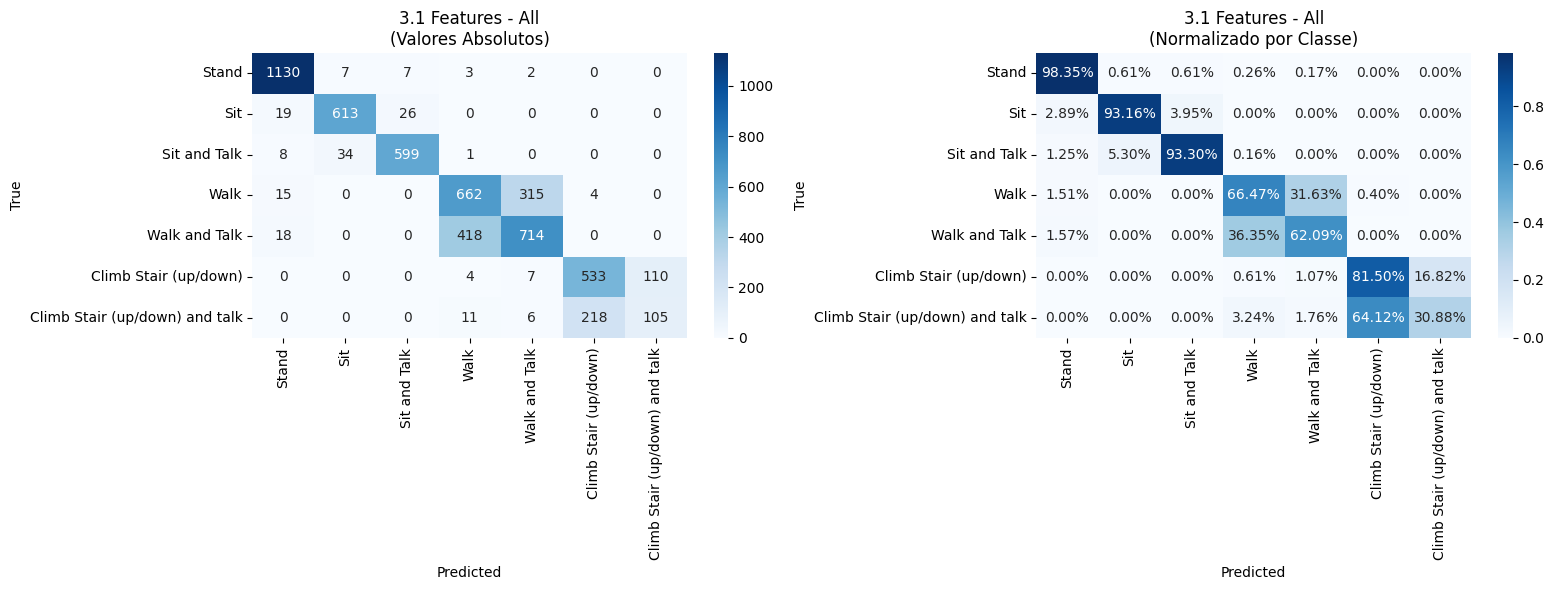


ANÁLISE DE ERROS: 3.1 Features - All

 RANKING DE DIFICULDADE (ordenado por F1-score):
--------------------------------------------------
1. Climb Stair (up/down) and talk F1: 0.378
2. Walk                 F1: 0.632
3. Walk and Talk        F1: 0.651
4. Climb Stair (up/down) F1: 0.757
5. Sit                  F1: 0.934
6. Sit and Talk         F1: 0.940
7. Stand                F1: 0.966

 CONFUSÕES MAIS FREQUENTES:
--------------------------------------------------
  Walk and Talk      → Walk               ( 418 erros, 36.3%)
  Walk               → Walk and Talk      ( 315 erros, 31.6%)
  Climb Stair (up/down) and talk → Climb Stair (up/down) ( 218 erros, 64.1%)
  Climb Stair (up/down) → Climb Stair (up/down) and talk ( 110 erros, 16.8%)
  Sit and Talk       → Sit                (  34 erros, 5.3%)
  Sit                → Sit and Talk       (  26 erros, 4.0%)
  Sit                → Stand              (  19 erros, 2.9%)
  Walk and Talk      → Stand              (  18 erros, 1.6%)
  Walk    

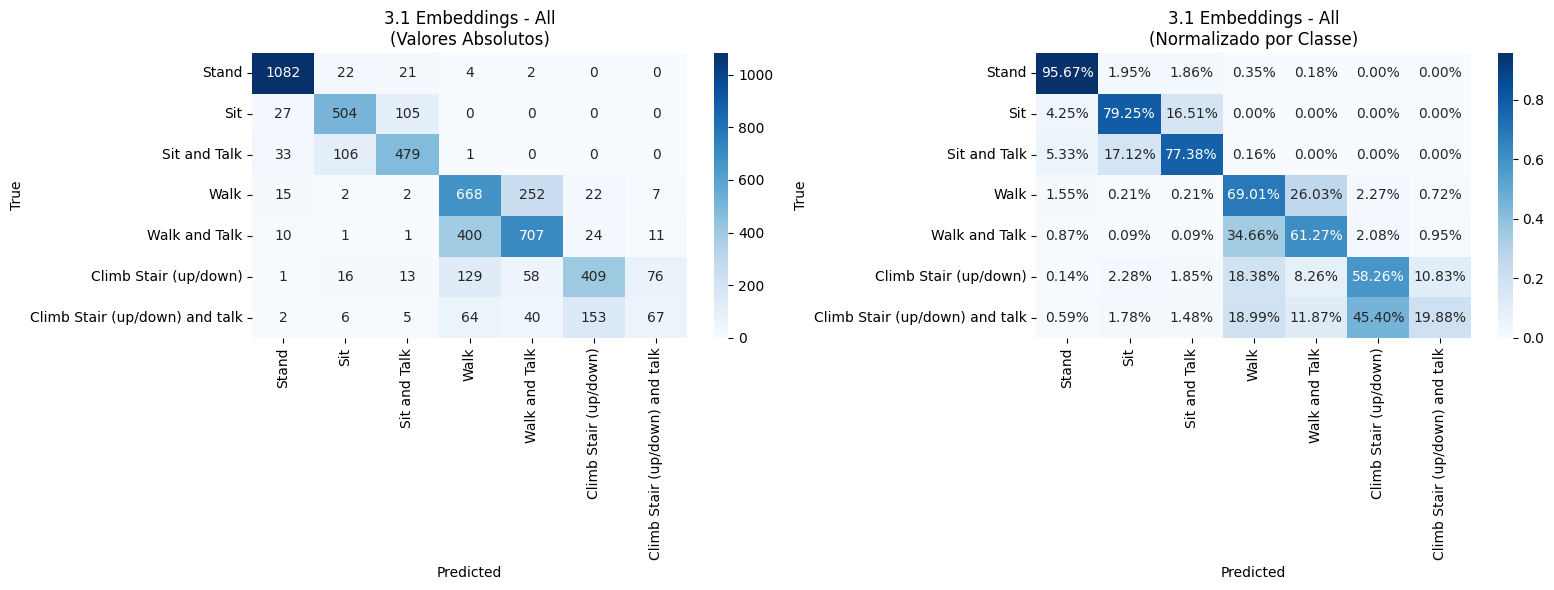


ANÁLISE DE ERROS: 3.1 Embeddings - All

 RANKING DE DIFICULDADE (ordenado por F1-score):
--------------------------------------------------
1. Climb Stair (up/down) and talk F1: 0.269
2. Walk                 F1: 0.598
3. Climb Stair (up/down) F1: 0.624
4. Walk and Talk        F1: 0.639
5. Sit and Talk         F1: 0.769
6. Sit                  F1: 0.780
7. Stand                F1: 0.940

 CONFUSÕES MAIS FREQUENTES:
--------------------------------------------------
  Walk and Talk      → Walk               ( 400 erros, 34.7%)
  Walk               → Walk and Talk      ( 252 erros, 26.0%)
  Climb Stair (up/down) and talk → Climb Stair (up/down) ( 153 erros, 45.4%)
  Climb Stair (up/down) → Walk               ( 129 erros, 18.4%)
  Sit and Talk       → Sit                ( 106 erros, 17.1%)
  Sit                → Sit and Talk       ( 105 erros, 16.5%)
  Climb Stair (up/down) → Climb Stair (up/down) and talk (  76 erros, 10.8%)
  Climb Stair (up/down) and talk → Walk               (  64 err

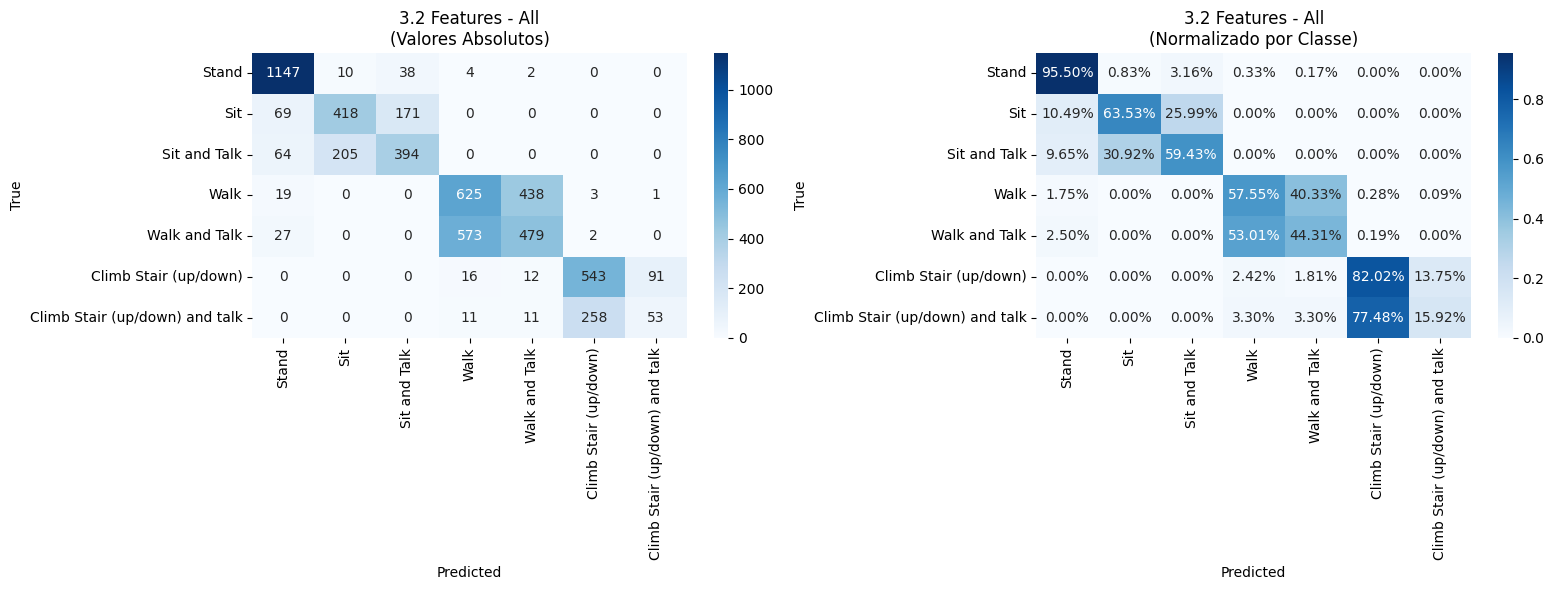


ANÁLISE DE ERROS: 3.2 Features - All

 RANKING DE DIFICULDADE (ordenado por F1-score):
--------------------------------------------------
1. Climb Stair (up/down) and talk F1: 0.222
2. Walk and Talk        F1: 0.474
3. Walk                 F1: 0.540
4. Sit and Talk         F1: 0.622
5. Sit                  F1: 0.648
6. Climb Stair (up/down) F1: 0.740
7. Stand                F1: 0.908

 CONFUSÕES MAIS FREQUENTES:
--------------------------------------------------
  Walk and Talk      → Walk               ( 573 erros, 53.0%)
  Walk               → Walk and Talk      ( 438 erros, 40.3%)
  Climb Stair (up/down) and talk → Climb Stair (up/down) ( 258 erros, 77.5%)
  Sit and Talk       → Sit                ( 205 erros, 30.9%)
  Sit                → Sit and Talk       ( 171 erros, 26.0%)
  Climb Stair (up/down) → Climb Stair (up/down) and talk (  91 erros, 13.7%)
  Sit                → Stand              (  69 erros, 10.5%)
  Sit and Talk       → Stand              (  64 erros, 9.7%)
  Stand

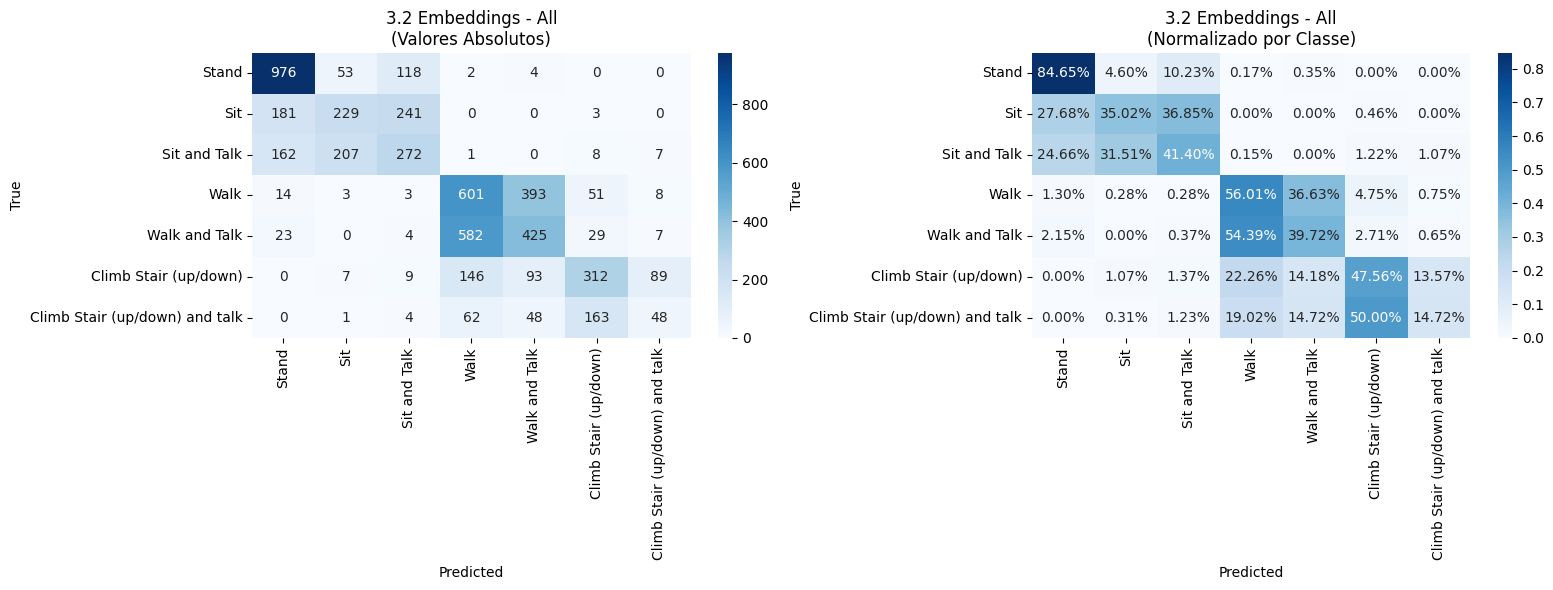


ANÁLISE DE ERROS: 3.2 Embeddings - All

 RANKING DE DIFICULDADE (ordenado por F1-score):
--------------------------------------------------
1. Climb Stair (up/down) and talk F1: 0.198
2. Sit                  F1: 0.397
3. Sit and Talk         F1: 0.416
4. Walk and Talk        F1: 0.418
5. Walk                 F1: 0.487
6. Climb Stair (up/down) F1: 0.511
7. Stand                F1: 0.778

 CONFUSÕES MAIS FREQUENTES:
--------------------------------------------------
  Walk and Talk      → Walk               ( 582 erros, 54.4%)
  Walk               → Walk and Talk      ( 393 erros, 36.6%)
  Sit                → Sit and Talk       ( 241 erros, 36.9%)
  Sit and Talk       → Sit                ( 207 erros, 31.5%)
  Sit                → Stand              ( 181 erros, 27.7%)
  Climb Stair (up/down) and talk → Climb Stair (up/down) ( 163 erros, 50.0%)
  Sit and Talk       → Stand              ( 162 erros, 24.7%)
  Climb Stair (up/down) → Walk               ( 146 erros, 22.3%)
  Stand         

In [129]:
activity_names = {
    1: 'Stand',
    2: 'Sit', 
    3: 'Sit and Talk',
    4: 'Walk',
    5: 'Walk and Talk',
    6: 'Climb Stair (up/down)',
    7: 'Climb Stair (up/down) and talk'
}
def plot_confusion_matrix(y_true, y_pred, title, activity_names=activity_names):
    """Plota matriz de confusão com análise de erros"""
    cm = metrics.confusion_matrix(y_true, y_pred)
    labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    label_names = [activity_names.get(l, str(l)) for l in labels]
    
    # Normalizar por linha (recall por classe)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Matriz de confusão absoluta
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title(f'{title}\n(Valores Absolutos)')
    
    # Matriz de confusão normalizada (%)
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title(f'{title}\n(Normalizado por Classe)')
    
    plt.tight_layout()
    plt.show()
    
    return cm, cm_normalized

def analyze_confusion_errors(y_true, y_pred, name, activity_names=activity_names):
    """Analisa os erros mais comuns na classificação"""
    cm = metrics.confusion_matrix(y_true, y_pred)
    labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    
    print(f"\n{'='*60}")
    print(f"ANÁLISE DE ERROS: {name}")
    print('='*60)
    
    # Calcular métricas por classe
    report = metrics.classification_report(y_true, y_pred, output_dict=True)
    
    # Identificar atividades mais difíceis (menor F1-score)
    class_f1 = []
    for label in labels:
        f1 = report[str(label)]['f1-score']
        class_f1.append((label, activity_names.get(label, str(label)), f1))
    
    class_f1.sort(key=lambda x: x[2])
    
    print("\n RANKING DE DIFICULDADE (ordenado por F1-score):")
    print("-"*50)
    for rank, (label, name_act, f1) in enumerate(class_f1, 1):
        print(f"{rank}. {name_act:<20} F1: {f1:.3f}")
    
    # Identificar confusões mais frequentes
    print("\n CONFUSÕES MAIS FREQUENTES:")
    print("-"*50)
    
    confusions = []
    for i, true_label in enumerate(labels):
        for j, pred_label in enumerate(labels):
            if i != j and cm[i, j] > 0:
                confusions.append({
                    'true': activity_names.get(true_label, str(true_label)),
                    'pred': activity_names.get(pred_label, str(pred_label)),
                    'count': cm[i, j],
                    'percent': cm[i, j] / cm[i].sum() * 100
                })
    
    confusions.sort(key=lambda x: x['count'], reverse=True)
    
    for conf in confusions[:10]:  # Top 10 confusões
        print(f"  {conf['true']:<18} → {conf['pred']:<18} ({conf['count']:>4} erros, {conf['percent']:.1f}%)")
    
    return class_f1, confusions

# Plotar matrizes de confusão para os melhores modelos de cada split
print("\n" + "="*80)
print("5.2 - ANÁLISE DAS MATRIZES DE CONFUSÃO")
print("="*80)

# Selecionar modelos para análise detalhada
models_to_analyze = [
    ("3.1 Features - All", 0),
    ("3.1 Embeddings - All", 3),
    ("3.2 Features - All", 6),
    ("3.2 Embeddings - All", 9),
]

all_analysis = {}

for name, idx in models_to_analyze:
    result = all_results[idx]
    
    # Plot confusion matrix
    cm, cm_norm = plot_confusion_matrix(result['y_true'], result['y_pred'], name)
    
    # Analyze errors
    class_f1, confusions = analyze_confusion_errors(result['y_true'], result['y_pred'], name)
    
    all_analysis[name] = {
        'cm': cm,
        'cm_normalized': cm_norm,
        'class_f1': class_f1,
        'confusions': confusions
    }


COMPARAÇÃO DE PERFORMANCE POR ATIVIDADE


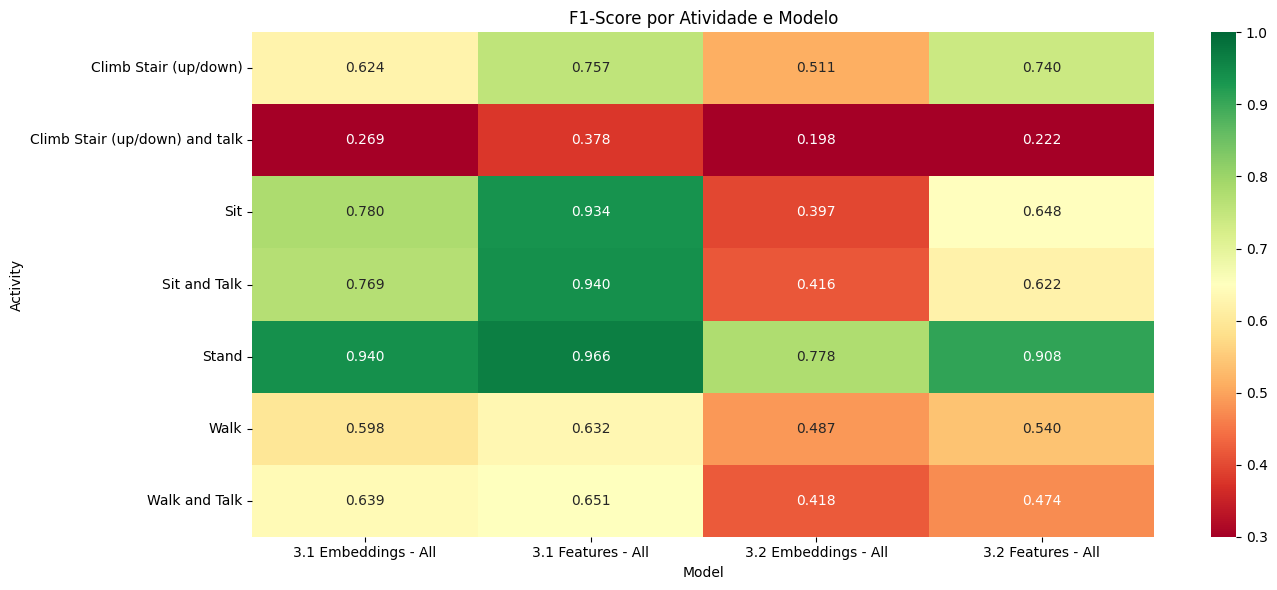


MÉDIA DE F1-SCORE POR ATIVIDADE (todos os modelos):
--------------------------------------------------
 Climb Stair (up/down) and talk Média F1: 0.267
 Walk and Talk        Média F1: 0.545
 Walk                 Média F1: 0.564
 Climb Stair (up/down) Média F1: 0.658
 Sit and Talk         Média F1: 0.687
 Sit                  Média F1: 0.690
 Stand                Média F1: 0.898


In [130]:
# === Comparação entre modelos ===

def compare_class_performance(all_results, activity_names=activity_names):
    """Compara performance por classe entre diferentes modelos"""
    
    print("\n" + "="*80)
    print("COMPARAÇÃO DE PERFORMANCE POR ATIVIDADE")
    print("="*80)
    
    # Preparar dados
    models = ["3.1 Features - All", "3.1 Embeddings - All", 
              "3.2 Features - All", "3.2 Embeddings - All"]
    indices = [0, 3, 6, 9]
    
    # Criar DataFrame com F1-scores por classe
    data = []
    for name, idx in zip(models, indices):
        result = all_results[idx]
        report = metrics.classification_report(result['y_true'], result['y_pred'], output_dict=True)
        
        for label in sorted(np.unique(result['y_true'])):
            data.append({
                'Model': name,
                'Activity': activity_names.get(label, str(label)),
                'F1-Score': report[str(label)]['f1-score'],
                'Precision': report[str(label)]['precision'],
                'Recall': report[str(label)]['recall']
            })
    
    df = pd.DataFrame(data)
    
    # Plot comparativo
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Pivot para heatmap
    pivot_df = df.pivot(index='Activity', columns='Model', values='F1-Score')
    
    sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='RdYlGn', 
                vmin=0.3, vmax=1.0, ax=ax)
    ax.set_title('F1-Score por Atividade e Modelo')
    plt.tight_layout()
    plt.show()
    
    # Identificar atividades mais problemáticas globalmente
    print("\nMÉDIA DE F1-SCORE POR ATIVIDADE (todos os modelos):")
    print("-"*50)
    avg_by_activity = df.groupby('Activity')['F1-Score'].mean().sort_values()
    
    for activity, f1_avg in avg_by_activity.items():
        print(f" {activity:<20} Média F1: {f1_avg:.3f}")
    
    return df

# Executar comparação
comparison_df = compare_class_performance(all_results)

In [131]:
# === Resumo em Markdown para o relatório ===

def generate_summary_markdown(all_results, activity_names=activity_names):
    """Gera resumo textual da análise"""
    
    print("\n" + "="*80)
    print("RESUMO DA ANÁLISE (para incluir no relatório)")
    print("="*80)
    
    # Melhor modelo geral
    best_model = max(all_results, key=lambda x: x['test_f1_macro'])
    print(f"\n MELHOR MODELO: {best_model['name']}")
    print(f"   F1 Macro: {best_model['test_f1_macro']:.4f}")
    print(f"   Accuracy: {best_model['test_acc']:.4f}")
    
    # Análise do melhor modelo
    report = metrics.classification_report(best_model['y_true'], best_model['y_pred'], output_dict=True)
    
    # Atividade mais fácil
    best_class = max(range(1, 8), key=lambda x: report[str(x)]['f1-score'] if str(x) in report else 0)
    worst_class = min(range(1, 8), key=lambda x: report[str(x)]['f1-score'] if str(x) in report else 1)
    
    print(f"\n Atividade MAIS FÁCIL: {activity_names[best_class]}")
    print(f"   F1: {report[str(best_class)]['f1-score']:.3f}")
    
    print(f"\n Atividade MAIS DIFÍCIL: {activity_names[worst_class]}")
    print(f"   F1: {report[str(worst_class)]['f1-score']:.3f}")
    
    # Confusões principais
    cm = metrics.confusion_matrix(best_model['y_true'], best_model['y_pred'])
    labels = sorted(np.unique(best_model['y_true']))
    
    print("\n  PRINCIPAIS CONFUSÕES:")
    confusions = []
    for i, true_label in enumerate(labels):
        for j, pred_label in enumerate(labels):
            if i != j and cm[i, j] > 0:
                confusions.append((true_label, pred_label, cm[i, j]))
    
    confusions.sort(key=lambda x: x[2], reverse=True)
    for true_l, pred_l, count in confusions[:5]:
        print(f"   • {activity_names[true_l]} confundido com {activity_names[pred_l]}: {count} casos")

generate_summary_markdown(all_results)


RESUMO DA ANÁLISE (para incluir no relatório)

 MELHOR MODELO: 3.1 Features - All
   F1 Macro: 0.7513
   Accuracy: 0.7794

 Atividade MAIS FÁCIL: Stand
   F1: 0.966

 Atividade MAIS DIFÍCIL: Climb Stair (up/down) and talk
   F1: 0.378

  PRINCIPAIS CONFUSÕES:
   • Walk and Talk confundido com Walk: 418 casos
   • Walk confundido com Walk and Talk: 315 casos
   • Climb Stair (up/down) and talk confundido com Climb Stair (up/down): 218 casos
   • Climb Stair (up/down) confundido com Climb Stair (up/down) and talk: 110 casos
   • Sit and Talk confundido com Sit: 34 casos


### 5.3 Perform hypothesis testing to compare the models
Is the best model statistically significantly better than the others? Justify the choice of the statistical tests you use. (NOTE: repeat the train-validation-test split several times to obtain the performance distributions of each model)

-------------------------------------------------------------------------------

## 6 - Deployment
Pick the best model from question 5 and make a function that receives a numpy array of shape 256 lines and 9 columns (acc x y z, gyr x y z, mag x y z) and performs all the necessary steps to return a classification from the model (normalization, feature extraction / embeddings generation, [PCA, Feature Selection], classification).

-------------------------------------------------------------------------------

## 7 - Go further
Discuss what can be done more to improve your classification system.

### 7.1 (BONUS) Implement and evaluate some of those ideas!